In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [57]:
#adding different data set for better prediction
df1 = pd.read_csv("dataset1.csv")
df2 = pd.read_csv("dataset2.csv")
df3 = pd.read_csv("dataset3.csv")

In [9]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_'], dtype='object')
Index(['date', 'state', 'district', 'pincode', 'demo_age_5_17',
       'demo_age_17_'],
      dtype='object')
Index(['date', 'state', 'district', 'pincode', 'age_0_5', 'age_5_17',
       'age_18_greater'],
      dtype='object')


In [10]:
keys = ["State", "Year"]

In [11]:
for df in [df1, df2, df3]:
    df.columns = df.columns.str.lower().str.strip()

In [12]:
keys = ["date", "state", "district", "pincode"]

merged12 = pd.merge(df1, df2, on=keys, how="inner")

In [13]:
final_df = pd.merge(merged12, df3, on=keys, how="inner")

In [14]:
final_df.head()
final_df.shape

(2623, 11)

In [15]:
final_df["total_5_17"] = final_df["bio_age_5_17"] + final_df["demo_age_5_17"]

In [16]:
final_df.head()

,date,state,district,pincode,bio_age_5_17,bio_age_17_,demo_age_5_17,demo_age_17_,age_0_5,age_5_17,age_18_greater,total_5_17
0,02-01-2026,Maharashtra,Mumbai Suburban,400029,2,0,0,3,1,0,0,2
1,02-01-2026,Maharashtra,Mumbai Suburban,400053,10,5,4,31,2,5,0,14
2,02-01-2026,Maharashtra,Mumbai Suburban,400058,15,8,2,25,3,0,0,17
3,02-01-2026,Maharashtra,Mumbai Suburban,400060,13,7,5,20,4,1,0,18
4,02-01-2026,Maharashtra,Mumbai Suburban,400065,12,7,3,25,1,0,0,15


In [17]:
final_df.tail()

,date,state,district,pincode,bio_age_5_17,bio_age_17_,demo_age_5_17,demo_age_17_,age_0_5,age_5_17,age_18_greater,total_5_17
2618,26-12-2025,Maharashtra,Mumbai Suburban,400066,6,17,2,33,2,0,0,8
2619,26-12-2025,Maharashtra,Mumbai Suburban,400088,14,13,3,23,2,0,0,17
2620,26-12-2025,Maharashtra,Mumbai Suburban,400093,12,7,0,17,4,0,0,12
2621,26-12-2025,Maharashtra,Mumbai Suburban,400097,16,14,8,64,6,0,0,24
2622,26-12-2025,Maharashtra,Mumbai Suburban,400103,2,3,1,12,4,0,0,3


In [18]:
final_df.isnull().sum()

,0
date,0
state,0
district,0
pincode,0
bio_age_5_17,0
bio_age_17_,0
demo_age_5_17,0
demo_age_17_,0
age_0_5,0
age_5_17,0


In [19]:
final_df.columns = final_df.columns.str.lower().str.strip() #it makes colum name clean so that no name can have extra space in between the column name

In [20]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2623 entries, 0 to 2622
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   date            2623 non-null   object
 1   state           2623 non-null   object
 2   district        2623 non-null   object
 3   pincode         2623 non-null   int64 
 4   bio_age_5_17    2623 non-null   int64 
 5   bio_age_17_     2623 non-null   int64 
 6   demo_age_5_17   2623 non-null   int64 
 7   demo_age_17_    2623 non-null   int64 
 8   age_0_5         2623 non-null   int64 
 9   age_5_17        2623 non-null   int64 
 10  age_18_greater  2623 non-null   int64 
 11  total_5_17      2623 non-null   int64 
dtypes: int64(9), object(3)
memory usage: 246.0+ KB


In [21]:
final_df["date"] = pd.to_datetime(final_df["date"], errors="coerce")

In [22]:
final_df = final_df.dropna(subset=["date"])

In [23]:
final_df.isnull().sum()

,0
date,0
state,0
district,0
pincode,0
bio_age_5_17,0
bio_age_17_,0
demo_age_5_17,0
demo_age_17_,0
age_0_5,0
age_5_17,0


In [24]:
final_df = final_df.drop_duplicates()

In [25]:
text_cols = ["state", "district"]

for col in text_cols:
    final_df[col] = final_df[col].str.title().str.strip()

In [26]:
final_df["total_5_17"] = final_df["bio_age_5_17"] + final_df["demo_age_5_17"]

In [27]:
final_df.head()

,date,state,district,pincode,bio_age_5_17,bio_age_17_,demo_age_5_17,demo_age_17_,age_0_5,age_5_17,age_18_greater,total_5_17
0,2026-02-01,Maharashtra,Mumbai Suburban,400029,2,0,0,3,1,0,0,2
1,2026-02-01,Maharashtra,Mumbai Suburban,400053,10,5,4,31,2,5,0,14
2,2026-02-01,Maharashtra,Mumbai Suburban,400058,15,8,2,25,3,0,0,17
3,2026-02-01,Maharashtra,Mumbai Suburban,400060,13,7,5,20,4,1,0,18
4,2026-02-01,Maharashtra,Mumbai Suburban,400065,12,7,3,25,1,0,0,15


In [28]:
final_df.shape

(813, 12)

In [29]:
final_df.to_csv("cleaned_uidai_data.csv", index=False)

In [30]:
from google.colab import files
files.download("cleaned_uidai_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:

df = pd.read_csv("cleaned_uidai_data.csv")
df.head()

,date,state,district,pincode,bio_age_5_17,bio_age_17_,demo_age_5_17,demo_age_17_,age_0_5,age_5_17,age_18_greater,total_5_17
0,2026-02-01,Maharashtra,Mumbai Suburban,400029,2,0,0,3,1,0,0,2
1,2026-02-01,Maharashtra,Mumbai Suburban,400053,10,5,4,31,2,5,0,14
2,2026-02-01,Maharashtra,Mumbai Suburban,400058,15,8,2,25,3,0,0,17
3,2026-02-01,Maharashtra,Mumbai Suburban,400060,13,7,5,20,4,1,0,18
4,2026-02-01,Maharashtra,Mumbai Suburban,400065,12,7,3,25,1,0,0,15


In [32]:
df.shape

(813, 12)

In [33]:
df.columns

Index(['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_',
       'demo_age_5_17', 'demo_age_17_', 'age_0_5', 'age_5_17',
       'age_18_greater', 'total_5_17'],
      dtype='object')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 813 entries, 0 to 812
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   date            813 non-null    object
 1   state           813 non-null    object
 2   district        813 non-null    object
 3   pincode         813 non-null    int64 
 4   bio_age_5_17    813 non-null    int64 
 5   bio_age_17_     813 non-null    int64 
 6   demo_age_5_17   813 non-null    int64 
 7   demo_age_17_    813 non-null    int64 
 8   age_0_5         813 non-null    int64 
 9   age_5_17        813 non-null    int64 
 10  age_18_greater  813 non-null    int64 
 11  total_5_17      813 non-null    int64 
dtypes: int64(9), object(3)
memory usage: 76.3+ KB


In [35]:
df["total_5_17"] = df["bio_age_5_17"] + df["demo_age_5_17"]
df["total_5_17"].sum()

np.int64(16750)

In [36]:
state_data = df.groupby("state")["total_5_17"].sum().sort_values(ascending=False)
state_data.head(10)

,total_5_17
state,
Maharashtra,16750


Biometric vs Demographic (age 5–17)

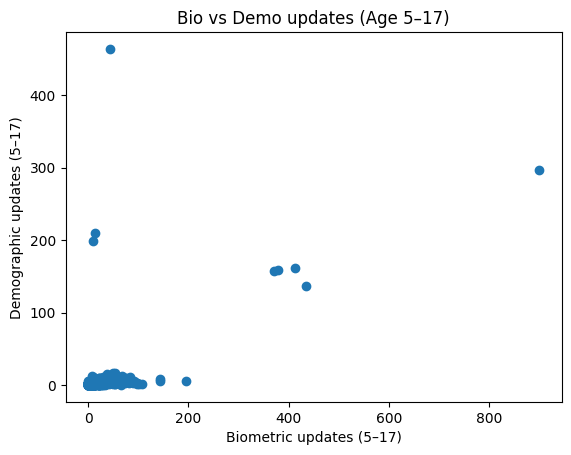

In [37]:
plt.figure()
plt.scatter(df["bio_age_5_17"], df["demo_age_5_17"])
plt.xlabel("Biometric updates (5–17)")
plt.ylabel("Demographic updates (5–17)")
plt.title("Bio vs Demo updates (Age 5–17)")
plt.show()
#This shows whether when biometric updates increase, demographic also increase.

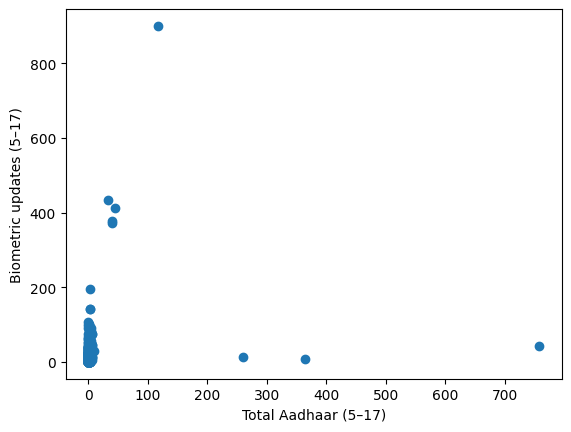

In [38]:
plt.figure()
plt.scatter(df["age_5_17"], df["bio_age_5_17"])
plt.xlabel("Total Aadhaar (5–17)")
plt.ylabel("Biometric updates (5–17)")
plt.show()
#Shows how much biometric activity depends on total Aadhaar count

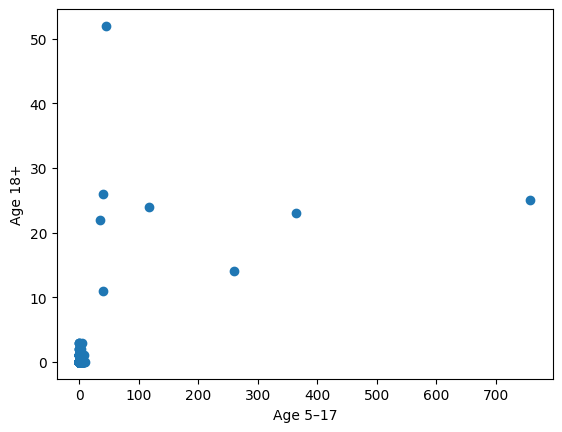

In [39]:
plt.figure()
plt.scatter(df["age_5_17"], df["age_18_greater"])
plt.xlabel("Age 5–17")
plt.ylabel("Age 18+")
plt.show()
#Helps understand child vs adult Aadhaar growth trend

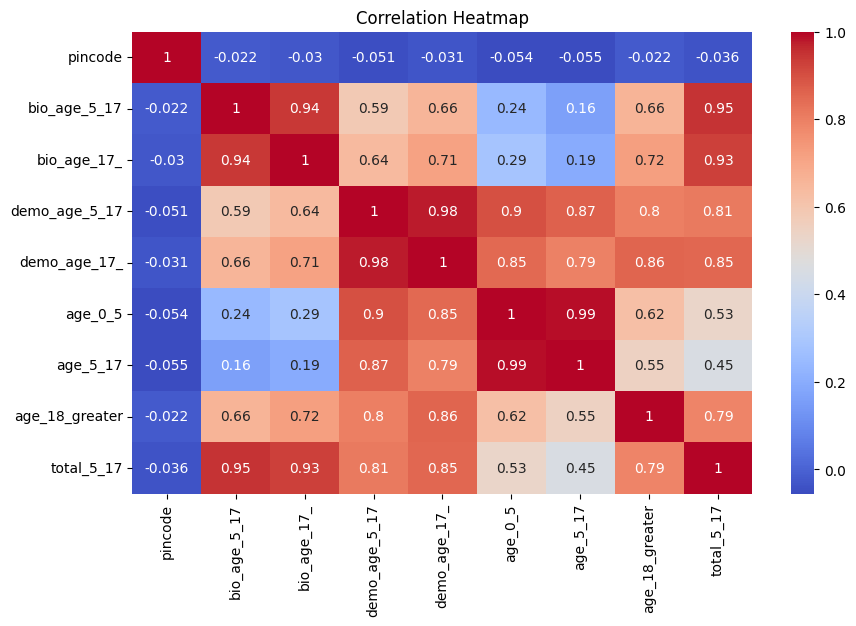

In [40]:
corr = df.select_dtypes(include="number").corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

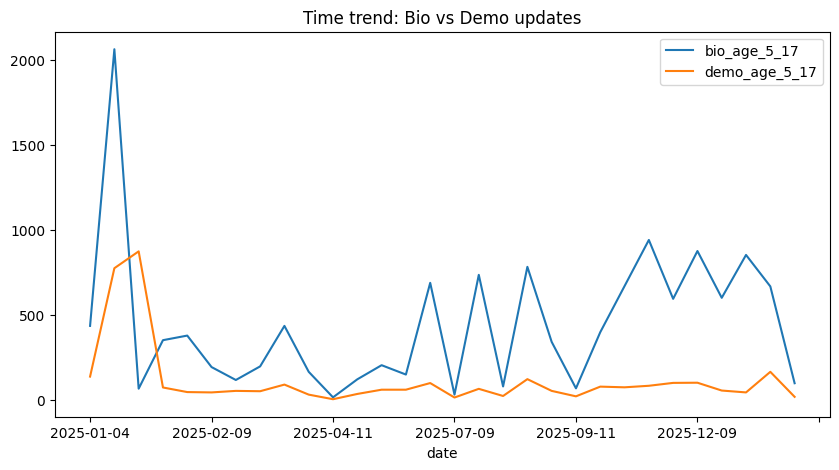

In [41]:
time_data = df.groupby("date")[["bio_age_5_17","demo_age_5_17"]].sum()
time_data.plot(figsize=(10,5))
plt.title("Time trend: Bio vs Demo updates")
plt.show()
#Shows when updates increased or decreased over time

*Using historical UIDAI data, we predict future Aadhaar update volume for the age group 5–17 to help identify high-demand regions and improve service planning

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_uidai_data.csv")
df["date"] = pd.to_datetime(df["date"])

In [44]:
#We predict total updates (bio + demo) for age 5–17.
df["total_5_17"] = df["bio_age_5_17"] + df["demo_age_5_17"]

In [45]:
daily = df.groupby("date")["total_5_17"].sum().reset_index()
daily.head()

,date,total_5_17
0,2025-01-04,572
1,2025-01-05,2835
2,2025-01-07,939
3,2025-01-09,424
4,2025-01-11,424


In [46]:
daily = daily.sort_values("date")

In [47]:
daily["date_num"] = daily["date"].map(pd.Timestamp.toordinal)
#convert date to number for ml

In [48]:
X = daily[["date_num"]]
y = daily["total_5_17"]

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#Train–test split

In [50]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [51]:
daily["predicted"] = model.predict(X)

In [52]:
#Predict future 30 days
last_date = daily["date"].max()
future_dates = pd.date_range(last_date, periods=30)

future_df = pd.DataFrame({
    "date": future_dates,
    "date_num": future_dates.map(pd.Timestamp.toordinal)
})

future_df["predicted_updates"] = model.predict(future_df[["date_num"]])
future_df.head()

,date,date_num,predicted_updates
0,2026-03-01,739676,482.214478
1,2026-03-02,739677,481.817427
2,2026-03-03,739678,481.420376
3,2026-03-04,739679,481.023324
4,2026-03-05,739680,480.626273


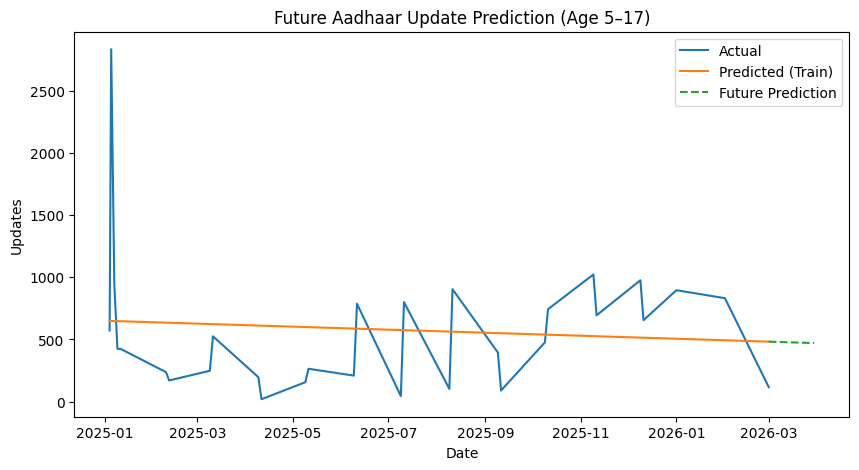

In [53]:
#plot pridiction
plt.figure(figsize=(10,5))
plt.plot(daily["date"], daily["total_5_17"], label="Actual")
plt.plot(daily["date"], daily["predicted"], label="Predicted (Train)")
plt.plot(future_df["date"], future_df["predicted_updates"],
         linestyle="--", label="Future Prediction")

plt.legend()
plt.title("Future Aadhaar Update Prediction (Age 5–17)")
plt.xlabel("Date")
plt.ylabel("Updates")
plt.show()